# 06. Year-to-year balance attribution

Attribute every annual change in the General Government balance to changes in the three subsectors, and distinguish the level of a balance from its contribution to an annual movement.

**Reads**

- `outputs/tables/balance_change_attribution.csv`
- `outputs/tables/largest_balance_movements.csv`

**Writes**

- Nothing. Both tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 6

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. An exact decomposition

$$\Delta B^{GG}_t = \Delta B^{C}_t + \Delta B^{RL}_t + \Delta B^{SSF}_t.$$

This holds by construction, so the table is a reallocation of an observed change
rather than an estimate.

The same change is also reported scaled by current-year GDP. Because the three
terms then share one denominator, the scaled version decomposes exactly as well:

$$\frac{\Delta B^{GG}_t}{GDP_t} = \frac{\Delta B^{C}_t}{GDP_t} + \frac{\Delta B^{RL}_t}{GDP_t} + \frac{\Delta B^{SSF}_t}{GDP_t}.$$

That is **not** the change in the balance ratio, which would also move with the
denominator and would not decompose additively. The scaling exists so that years
can be compared in size: ranking movements on nominal euro effectively ranks them
by how recent they are.

In [2]:
attribution = pd.read_csv(TABLES / 'balance_change_attribution.csv')
change_columns = [
    'year',
    'aggregate_change_m_eur',
    'central_change_m_eur',
    'regional_local_change_m_eur',
    'ssf_change_m_eur',
    'aggregate_change_pct_gdp',
    'change_closure_error_m_eur',
]
display(attribution[change_columns].tail(12).round(3))

,year,aggregate_change_m_eur,central_change_m_eur,regional_local_change_m_eur,ssf_change_m_eur,aggregate_change_pct_gdp,change_closure_error_m_eur
36,2014,-3854.0,-4659.0,346.0,460.0,-2.225,-1.0
37,2015,4726.0,4283.0,121.0,321.0,2.634,1.0
38,2016,4404.0,3876.0,87.0,441.0,2.363,0.0
39,2017,-2248.0,-2405.0,-515.0,673.0,-1.150,-1.0
40,2018,4997.0,5053.0,151.0,-208.0,2.438,1.0
41,2019,1122.0,76.0,105.0,940.0,0.523,1.0
42,2020,-11813.0,-10224.0,-811.0,-777.0,-5.876,-1.0
43,2021,5447.0,5570.0,-394.0,270.0,2.516,1.0
44,2022,5360.0,3019.0,510.0,1831.0,2.197,0.0
45,2023,3787.0,2519.0,-152.0,1421.0,1.401,-1.0


## 2. Both windows, drawn separately

The attribution is plotted as two panels that stop either side of 1995. A single
panel spanning the splice would place a vintage revision among the economic
movements and give it the same visual weight. The window is written into each
title, because a stacked bar chart gives the reader no other way to tell that
years are missing from the ends.

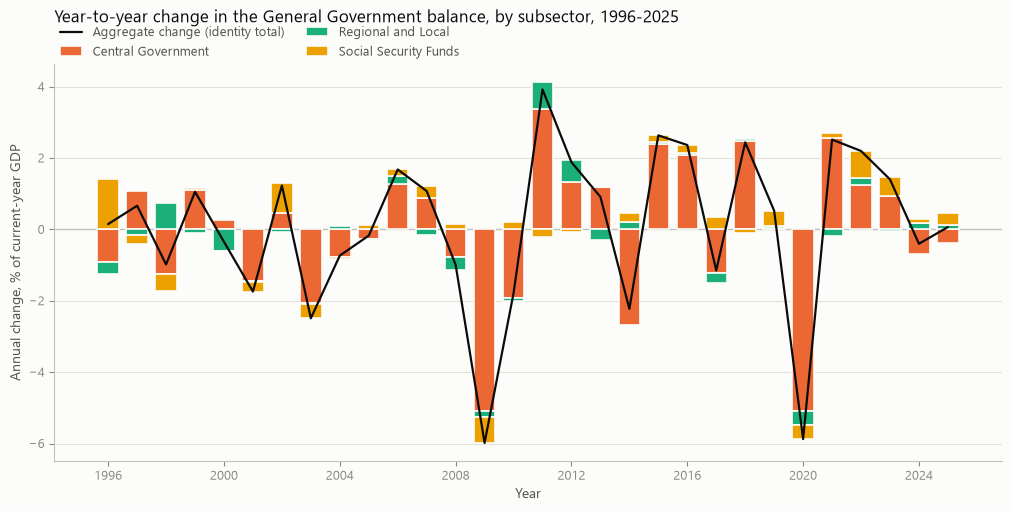

In [3]:
figure = figures.balance_change_attribution(attribution, start_year=1996, end_year=2025)

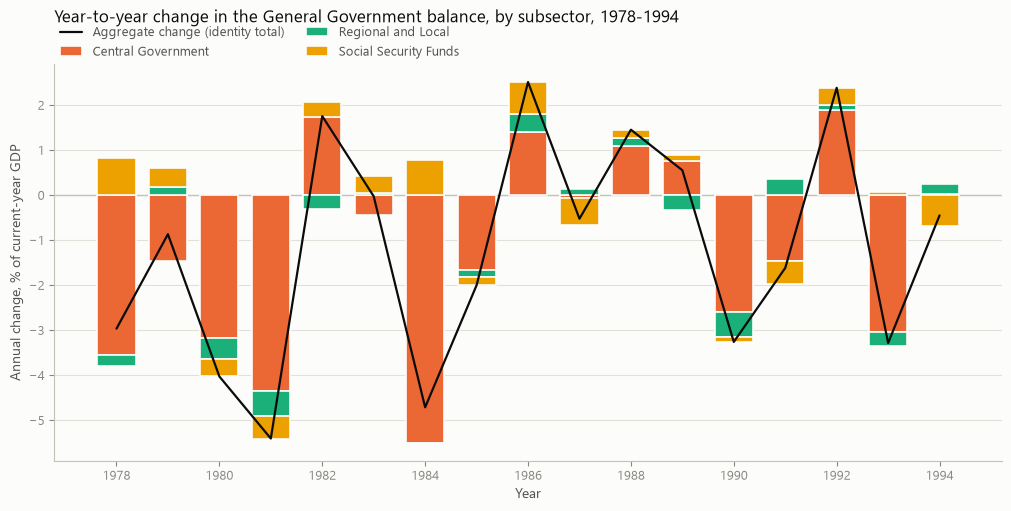

In [4]:
figure = figures.balance_change_attribution(attribution, start_year=1978, end_year=1994)

## 3. Contribution shares

Shares are expressed against the absolute aggregate change, so a share above one
means a subsector moved further than the aggregate and was partly offset by
another subsector. A negative share means the subsector moved against the
aggregate.

In [5]:
share_columns = [
    'year',
    'aggregate_change_m_eur',
    'central_change_share_abs_aggregate_change',
    'regional_local_change_share_abs_aggregate_change',
    'ssf_change_share_abs_aggregate_change',
]
largest = attribution.reindex(attribution['aggregate_change_m_eur'].abs().sort_values(ascending=False).index)
display(largest[share_columns].head(10).round(3))

,year,aggregate_change_m_eur,central_change_share_abs_aggregate_change,regional_local_change_share_abs_aggregate_change,ssf_change_share_abs_aggregate_change
42,2020,-11813.0,-0.865,-0.069,-0.066
31,2009,-10496.0,-0.852,-0.028,-0.121
33,2011,6913.0,0.859,0.194,-0.053
43,2021,5447.0,1.023,-0.072,0.050
44,2022,5360.0,0.563,0.095,0.342
40,2018,4997.0,1.011,0.030,-0.042
37,2015,4726.0,0.906,0.026,0.068
38,2016,4404.0,0.880,0.020,0.100
36,2014,-3854.0,-1.209,0.090,0.119
45,2023,3787.0,0.665,-0.040,0.375


## 4. The largest movements, ranked inside each regime

Ranked on the GDP-scaled change, which removes the recency bias of a nominal
ranking, and **within** each statistical regime rather than across both. Each annual
change is computed inside one source family and is sound, but ordering historical
against modern episodes by size would compare two methodologies -- the thing this
analysis refuses to do with magnitudes everywhere else.

1995 is excluded because that change straddles the vintage splice in both panels.

In [6]:
movements = pd.read_csv(TABLES / 'largest_balance_movements.csv')
display(
    movements[
        [
            'regime',
            'rank_in_regime',
            'year',
            'direction',
            'aggregate_change_pct_gdp',
            'aggregate_change_m_eur',
            'dominant_subsector',
            'dominant_subsector_share',
        ]
    ].round(3)
)

,regime,rank_in_regime,year,direction,aggregate_change_pct_gdp,aggregate_change_m_eur,dominant_subsector,dominant_subsector_share
0,1977-1994_historical,1,1981,deterioration,-5.401,-477.803,Central Government,-0.806
1,1977-1994_historical,2,1984,deterioration,-4.708,-790.159,Central Government,-1.167
2,1977-1994_historical,3,1980,deterioration,-4.023,-296.223,Central Government,-0.787
3,1977-1994_historical,4,1993,deterioration,-3.280,-2221.537,Central Government,-0.926
4,1977-1994_historical,5,1990,deterioration,-3.255,-1635.338,Central Government,-0.798
5,1995-2025_modern,1,2009,deterioration,-5.983,-10496.000,Central Government,-0.852
6,1995-2025_modern,2,2020,deterioration,-5.876,-11813.000,Central Government,-0.865
7,1995-2025_modern,3,2011,improvement,3.921,6913.000,Central Government,0.859
8,1995-2025_modern,4,2015,improvement,2.634,4726.000,Central Government,0.906
9,1995-2025_modern,5,2021,improvement,2.516,5447.000,Central Government,1.023


The attribution is hierarchical: the revenue and expenditure split below is of the
subsector that dominates each move, not of the aggregate, so both halves describe the
same entity. Expenditure enters the balance negatively, so its contribution is minus
the change.

In [7]:
display(
    movements[
        [
            'regime',
            'year',
            'dominant_subsector',
            'dominant_subsector_change_m_eur',
            'dominant_revenue_change_m_eur',
            'dominant_expenditure_contribution_m_eur',
            'dominant_split_error_m_eur',
        ]
    ].round(1)
)

,regime,year,dominant_subsector,dominant_subsector_change_m_eur,dominant_revenue_change_m_eur,dominant_expenditure_contribution_m_eur,dominant_split_error_m_eur
0,1977-1994_historical,1981,Central Government,-385.3,394.7,-780.0,-0.0
1,1977-1994_historical,1984,Central Government,-922.2,616.1,-1538.4,-0.0
2,1977-1994_historical,1980,Central Government,-233.1,387.5,-620.6,0.0
3,1977-1994_historical,1993,Central Government,-2057.3,-496.0,-1561.3,-0.0
4,1977-1994_historical,1990,Central Government,-1305.5,1866.3,-3171.8,0.0
5,1995-2025_modern,2009,Central Government,-8939.0,-3466.6,-5472.6,0.3
6,1995-2025_modern,2020,Central Government,-10224.0,-3748.3,-6475.4,-0.3
7,1995-2025_modern,2011,Central Government,5937.0,1209.1,4728.0,-0.1
8,1995-2025_modern,2015,Central Government,4283.0,1580.5,2702.6,-0.1
9,1995-2025_modern,2021,Central Government,5570.0,6854.9,-1285.0,0.1


## 5. Closure check

In [8]:
print('max |change-identity residual| (M EUR):', round(float(attribution['change_closure_error_m_eur'].abs().max()), 6))
print('observations:', len(attribution), 'covering', int(attribution['year'].min()), 'to', int(attribution['year'].max()))

max |change-identity residual| (M EUR): 1.0
observations: 48 covering 1978 to 2025


## Interpretation limits

1. **Contribution is not causation.** A subsector accounting for most of an
   annual improvement has not been shown to have produced it.
2. The 1994-to-1995 change crosses the **statistical splice** and mixes a
   vintage revision with an economic movement. It is excluded from the ranked
   episodes and from both figures.
3. **The GDP-scaled change is not the change in the balance ratio.** It shares a
   denominator so the decomposition stays exact.
4. Attribution operates on **balances only**. Whether a movement came from
   revenue or expenditure is the subject of notebook 05.

---

[Previous: 05. Revenue and expenditure decomposition](05_revenue_expenditure.ipynb) | [Next: 07. Balance persistence and sign transitions](07_persistence.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```